In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


3.1.1 Your Task:
Implement the Softmax and Prediction functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [2]:
import numpy as np

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable)

    softmax_output = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return softmax_output

In [3]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)

assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")

Softmax function passed the test case!


In [5]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b

    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [6]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


3.2.1 Your Task:
Implement the Loss and Cost functions using either of the following approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [7]:
import numpy as np

def compute_loss(y_true, y_pred):
    epsilon = 1e-9

    loss = -np.sum(y_true * np.log(y_pred + epsilon), axis=1)

    return loss

In [8]:
def compute_cost(y_true, y_pred):
    n = y_true.shape[0]

    loss = compute_loss(y_true, y_pred)

    cost = np.mean(loss)

    return cost

In [9]:
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

y_pred_test = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.8, 0.1],
    [0.2, 0.2, 0.6]
])

loss = compute_loss(y_test, y_pred_test)
cost = compute_cost(y_test, y_pred_test)

manual_loss = -np.log([0.7, 0.8, 0.6])
manual_cost = np.mean(manual_loss)

assert np.allclose(loss, manual_loss)
assert np.isclose(cost, manual_cost)

print("Loss:", loss)
print("Cost:", cost)
print("Test passed!")

Loss: [0.35667494 0.22314355 0.51082562]
Cost: 0.363548038224565
Test passed!


3.3.1 Your Task:
Implement the Compute Gradients and Gradient Descent functions using either of the following
approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.
Regardless of the approach you choose, your implementation must pass the provided test case without
any modifications to the test case itself.

In [10]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [11]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual)
assert np.allclose(grad_b, grad_b_manual)

print("Gradient test passed!")

Gradient test passed!


In [12]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        if show_cost:
            z = np.dot(X, W) + b
            y_pred = softmax(z)

            cost = -np.mean(np.sum(y * np.log(y_pred + 1e-9), axis=1))
            cost_history.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

3.4.1 Your Task:
Implement the load and prepare mnist; and plot sample images using either of the following
approaches:

• Build from scratch: Develop the functions independently based on the mathematical formula-
tion.

• Use the provided functional template: Complete the given function structure available in
the starter code.

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def load_and_prepare_mnist(file_path):

    df = pd.read_csv("/content/drive/MyDrive/AI and ML/mnist_dataset.csv")


    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values


    X = X / 255.0


    num_classes = 10
    y_onehot = np.zeros((y.shape[0], num_classes))
    y_onehot[np.arange(y.shape[0]), y] = 1


    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test, y

In [15]:
import matplotlib.pyplot as plt

def plot_sample_images(X, y_labels):
    plt.figure(figsize=(10,5))

    for digit in range(10):

        idx = np.where(y_labels == digit)[0][0]

        image = X[idx].reshape(28, 28)

        plt.subplot(2, 5, digit + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Train shape: (48000, 784)
Test shape: (12000, 784)


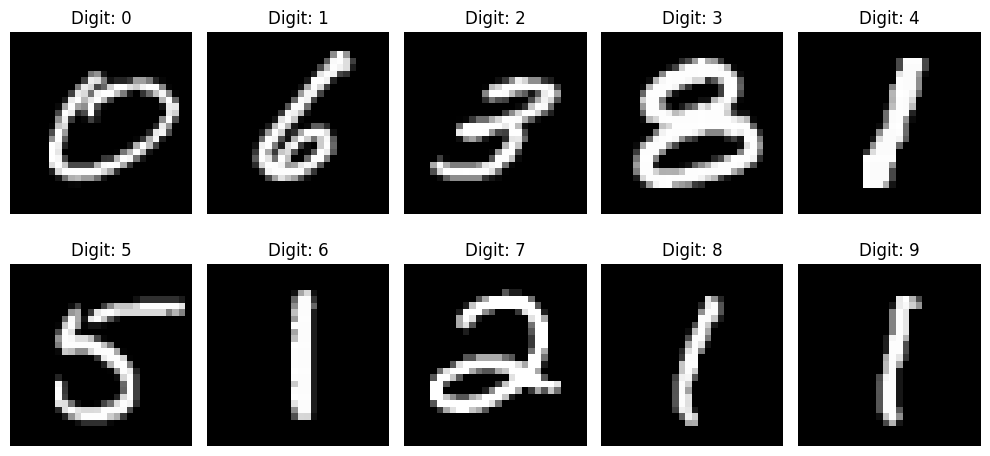

In [17]:


X_train, X_test, y_train, y_test, y_labels = load_and_prepare_mnist('mnist_dataset.csv')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


plot_sample_images(X_train, y_labels)

Initialize Parameters

In [18]:
import numpy as np

def initialize_parameters(n_features, n_classes):
    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)
    return W, b

Training the Model

In [19]:
# Initialize
n_features = X_train.shape[1]
n_classes = y_train.shape[1]

W, b = initialize_parameters(n_features, n_classes)

# Train
W, b, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b,
    alpha=0.1,
    n_iter=1000,
    show_cost=True
)

Iteration 0, Cost: 2.196695575530067
Iteration 100, Cost: 0.6070071779866039
Iteration 200, Cost: 0.4893882106600736
Iteration 300, Cost: 0.4408162920210631
Iteration 400, Cost: 0.41275435995611454
Iteration 500, Cost: 0.3938971799742499
Iteration 600, Cost: 0.38008228984957265
Iteration 700, Cost: 0.3693800512198484
Iteration 800, Cost: 0.36075927838897603
Iteration 900, Cost: 0.35361259171935094


Plot Cost

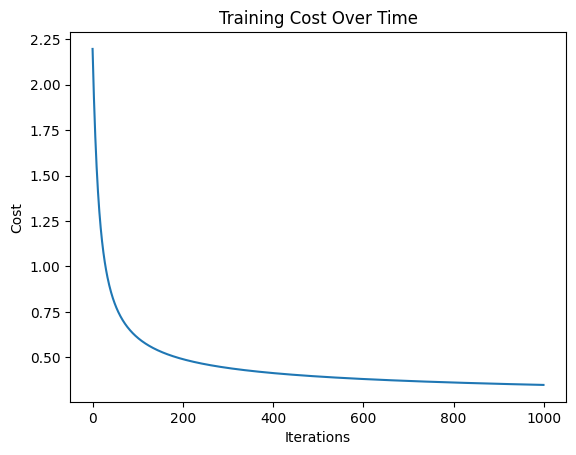

In [20]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost Over Time")
plt.show()

Prediction

In [21]:
def predict_labels(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

Accuracy

In [22]:
def compute_accuracy(X, y_true_onehot, W, b):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = predict_labels(X, W, b)

    accuracy = np.mean(y_true == y_pred)
    return accuracy

Evaluate Model

In [23]:
train_acc = compute_accuracy(X_train, y_train, W, b)
test_acc = compute_accuracy(X_test, y_test, W, b)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9038541666666666
Test Accuracy: 0.9043333333333333


plots, answer the following questions:




• Question - 2: Provide an interpretation of the output based on your understanding.

The plotted output displays one sample image for each digit from 0 to 9, reconstructed from the pixel values stored in the CSV file. Each image is represented as a 28×28 grayscale grid, where pixel intensity values correspond to the brightness of each pixel.

From the visualization, it is evident that the dataset has been correctly loaded and preprocessed, as the images resemble recognizable handwritten digits. This confirms that the feature extraction process—converting images into pixel values—was successful.

Additionally, the normalization step ensures that pixel values are scaled between 0 and 1, which improves the efficiency and stability of the learning process during model training.

Overall, the output verifies that the dataset is properly structured and suitable for training a softmax regression model for digit classification.

• Question - 3:


Describe any challenges you faced while implementing the code above.

Several challenges were encountered during the implementation:



Understanding Data Structure
Initially, it was unclear how the pixel values in the CSV file corresponded to the original image. Mapping the 784 features back into a 28×28 image required careful reshaping.

Handling Data Shapes
Ensuring the correct dimensions for input features, labels, and model parameters was challenging. Mistakes in shape alignment (e.g., during matrix multiplication) led to errors that required debugging.

One-Hot Encoding of Labels
Converting categorical labels into one-hot encoded vectors was necessary for computing loss and gradients. Implementing this correctly without errors required attention.

Numerical Stability Issues
While implementing softmax and loss functions, issues such as overflow and log(0) had to be handled using techniques like subtracting the maximum value and adding a small epsilon.

Visualization Issues
Displaying images correctly required reshaping the flattened pixel arrays into 28×28 format. Incorrect reshaping initially resulted in distorted images.